# Interdigital capacitor Q3D capacitance

This notebook builds and solves one public IDC coupon directly with PyAEDT.
The finite conductor named `ground` is a circuit node, not an ideal GroundNet.

## Setup and run controls

In [ ]:
from __future__ import annotations

import json
from pathlib import Path
from time import perf_counter, sleep

import gdsfactory as gf
import pandas as pd
from ansys.aedt.core import Q3d
from IPython.display import HTML, Image, clear_output, display
from IPython.utils.capture import capture_output

import orpen_sc_pdk
from orpen_sc_pdk.materials import get_material_records
from orpen_sc_pdk.simulation.aedt import (
    aedt_material_name_for_physical_material,
    aedt_material_name_from_physical_key,
    load_q3d_capacitance_result,
)
from orpen_sc_pdk.tech import (
    METAL_THICKNESS_UM,
    OUTER_VACUUM_THICKNESS_UM,
    SUBSTRATE_THICKNESS_UM,
)

REPO_ROOT = Path(orpen_sc_pdk.__file__).resolve().parent.parent
if not (REPO_ROOT / "orpen_sc_pdk").is_dir():
    raise RuntimeError("The active orpen_sc_pdk package is not a source checkout.")
orpen_sc_pdk.activate()

RUN_ID = "2026-08-10-idc-q3d-v2"
RUN_SOLVER = True
NON_GRAPHICAL = True
CLOSE_DESKTOP = True
SUPERCONDUCTING_METALS = True
METAL_KEY = "Al"
SUBSTRATE_KEY = "Si"
REGION_PADDING_UM = OUTER_VACUUM_THICKNESS_UM
ACF_PATH = REPO_ROOT / "notebooks" / "AEDTSimulation" / "Q3D_Local.acf"

RUN_DIR = REPO_ROOT / "build" / "simulation" / "aedt" / "interdigital_capacitor_q3d" / RUN_ID
GDS_PATH = RUN_DIR / "interdigital_capacitor_coupon.gds"
PROJECT_PATH = RUN_DIR / "interdigital_capacitor_q3d.aedt"
PLOT_PATH = RUN_DIR / "q3d_geometry.png"
MATRIX_PATH = RUN_DIR / "c_maxwell_matrix.csv"
TIMING_PATH = RUN_DIR / "solve_timing.json"
CONVERGENCE_DIR = RUN_DIR / "adaptive_passes"
CONVERGENCE_CSV_PATH = RUN_DIR / "capacitance_convergence.csv"
CONVERGENCE_PLOT_PATH = RUN_DIR / "capacitance_convergence.png"
Q3D_SETUP = {
    "name": "Setup1",
    "capacitance": {
        "MaxPass": 99,  # Maximum adaptive passes.
        "MinPass": 1,  # Minimum adaptive passes.
        "MinConvPass": 2,  # Consecutive converged passes required.
        "PerError": 0.1,  # Target capacitance change in percent.
        "PerRefine": 30,  # Mesh refinement per adaptive pass in percent.
        "AutoIncreaseSolutionOrder": True,
        "SolutionOrder": "High",
        "Solver Type": "Iterative",
    },
}

## Create and plot the registered coupon

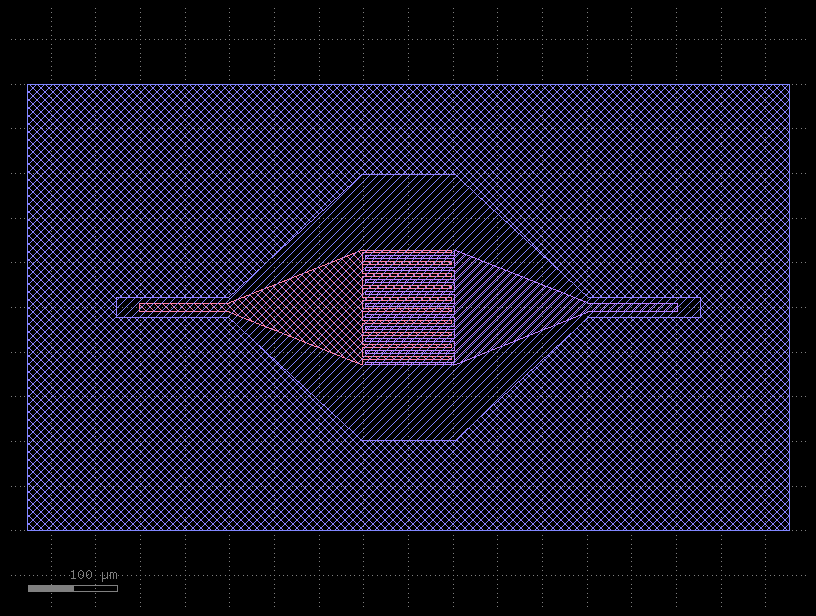

In [2]:
FINGERS = 20
FINGER_LENGTH_UM = 100.0
FINGER_GAP_UM = 3.3
FINGER_WIDTH_UM = 3.3
TAPER_LENGTH_UM = 150.0
TERMINAL_EXTENSION_LENGTH_UM = 100.0
CAPACITOR_GROUND_GAP_UM = 85.0
TERMINAL_OPEN_CLEARANCE_UM = 25.0
COUPON_MARGIN_UM = 100.0

coupon = gf.get_component(
    "interdigital_capacitor_q3d_coupon",
    fingers=FINGERS,
    finger_length=FINGER_LENGTH_UM,
    finger_gap=FINGER_GAP_UM,
    finger_width=FINGER_WIDTH_UM,
    taper_length=TAPER_LENGTH_UM,
    terminal_extension_length_um=TERMINAL_EXTENSION_LENGTH_UM,
    capacitor_ground_gap=CAPACITOR_GROUND_GAP_UM,
    terminal_open_clearance_um=TERMINAL_OPEN_CLEARANCE_UM,
    coupon_margin_um=COUPON_MARGIN_UM,
)
coupon.plot()

coupon_layers = coupon.info["q3d_coupon"]["layers"]
metal_condition = "cryogenic" if SUPERCONDUCTING_METALS else "room_temperature"
metal_material = aedt_material_name_for_physical_material(
    METAL_KEY,
    material_kind=get_material_records()[METAL_KEY]["material_kind"],
    material_condition=metal_condition,
)
substrate_material = aedt_material_name_from_physical_key(SUBSTRATE_KEY)
Q3D_LAYERS = {
    "signal_1": {
        "layer": tuple(coupon_layers["signal_1"]),
        "zmin": 0.0,
        "thickness": METAL_THICKNESS_UM,
        "material": metal_material,
    },
    "signal_2": {
        "layer": tuple(coupon_layers["signal_2"]),
        "zmin": 0.0,
        "thickness": METAL_THICKNESS_UM,
        "material": metal_material,
    },
    "ground": {
        "layer": tuple(coupon_layers["finite_ground"]),
        "zmin": 0.0,
        "thickness": METAL_THICKNESS_UM,
        "material": metal_material,
    },
    "substrate": {
        "layer": tuple(coupon_layers["substrate_footprint"]),
        "zmin": -SUBSTRATE_THICKNESS_UM,
        "thickness": SUBSTRATE_THICKNESS_UM,
        "material": substrate_material,
    },
}

## Initialize the Q3D project

In [ ]:
RUN_DIR.mkdir(parents=True, exist_ok=True)
RESUME_EXISTING_PROJECT = PROJECT_PATH.exists()
q3d = Q3d(
    project=str(PROJECT_PATH),
    design="idc_q3d_capacitance",
    solution_type="Q3D Extractor",
    non_graphical=NON_GRAPHICAL,
    new_desktop=True,
    close_on_exit=False,
)
q3d.modeler.model_units = "um"
# Reopened projects need an explicit PyAEDT object-cache refresh; without it,
# q3d.plot can render only axes even though AEDT owns saved geometry.
q3d.modeler.refresh_all_ids()
BUILD_MODEL = not q3d.modeler.object_names
print("Resuming existing project." if RESUME_EXISTING_PROJECT else "Created new project.")
if RESUME_EXISTING_PROJECT and BUILD_MODEL:
    print("The saved project contains no geometry; rebuilding it from the coupon GDS.")

PyAEDT INFO: Python version 3.12.13 (main, May 10 2026, 19:30:01) [Clang 22.1.3 ].
PyAEDT INFO: PyAEDT version 0.26.2.
PyAEDT INFO: Initializing new Desktop session.
PyAEDT INFO: AEDT version 2024.2.
PyAEDT INFO: New AEDT session is starting on gRPC port 36223.
PyAEDT INFO: Starting new AEDT gRPC session on port 36223.
PyAEDT INFO: Launching AEDT server with gRPC transport mode: TransportMode.UDS
PyAEDT INFO: Electronics Desktop started on gRPC port 36223 after 6.5 seconds.
PyAEDT INFO: AEDT installation Path /opt/AnsysEM/v242/Linux64
PyAEDT INFO: Connected to AEDT gRPC session on port 36223.
PyAEDT WARNING: Service Pack is not detected. PyAEDT is currently connecting in Insecure Mode.
PyAEDT WARNING: Please download and install latest Service Pack to use connect to AEDT in Secure Mode.


RuntimeError: Project is locked. Close or remove the lock before proceeding.

: 

## Import the GDS and build the Q3D model

In [ ]:
# A project can exist without saved geometry when an earlier post-processing cell
# failed before the final save. Rebuild only that empty-project case; otherwise
# preserve the saved model, mesh, and adaptive solution for cumulative solving.
if BUILD_MODEL:
    coupon.write_gds(GDS_PATH)

    gds_layer_mapping = {
        spec["layer"][0]: (spec["zmin"], spec["thickness"]) for spec in Q3D_LAYERS.values()
    }
    if not q3d.import_gds_3d(str(GDS_PATH), gds_layer_mapping, units="um", import_method=1):
        raise RuntimeError(f"Q3d.import_gds_3d failed for {GDS_PATH}")
    q3d.modeler.refresh_all_ids()

    for net_name, spec in Q3D_LAYERS.items():
        layer_number = spec["layer"][0]
        objects = [
            name for name in q3d.modeler.object_names if name.startswith(f"signal{layer_number}_")
        ]
        if len(objects) != 1:
            raise RuntimeError(f"Expected one imported object for {net_name}, found {objects!r}")
        imported = q3d.modeler.get_object_from_name(objects[0])
        imported.name = net_name
        imported.material_name = spec["material"]

    # Keep the GDS-extruded silicon substrate. Vacuum exists only as the AEDT Region.
    q3d.modeler.create_region(
        pad_value=[f"{REGION_PADDING_UM}um"] * 6,
        pad_type="Absolute Offset",
        name="Region",
    ).material_name = "vacuum"

    for net_name in ("ground", "signal_1", "signal_2"):
        q3d.assign_net(net_name, net_name=net_name, net_type="Signal")

    # Save the model before solving so a later plotting/export error cannot leave
    # an empty .aedt project that is impossible to resume.
    q3d.save_project()

## Geometry verification

The finite `ground`, `signal_1`, and `signal_2` conductors are all Signal nets,
so Q3D exports their full Maxwell matrix relative to infinity.

In [ ]:
with capture_output():
    _geometry_plotter = q3d.plot(
        show=False,
        output_file=str(PLOT_PATH),
        plot_air_objects=False,
        plot_as_separate_objects=True,
    )
print(f"Geometry plot: {PLOT_PATH}")
display(Image(filename=str(PLOT_PATH)))

## Q3D capacitance setup

In [ ]:
setup = (
    q3d.get_setup(Q3D_SETUP["name"])
    if Q3D_SETUP["name"] in q3d.setup_names
    else q3d.create_setup(Q3D_SETUP["name"])
)
# PyAEDT 1.3 still removes disabled AC/DC blocks from a copied property mapping.
# Reopened capacitance-only projects may omit those keys, so supply empty entries
# before update; PyAEDT removes them again from the AEDT setup arguments.
setup.props.setdefault("AC", {})
setup.props.setdefault("DC", {})
setup.capacitance_enabled = True
setup.ac_rl_enabled = False
setup.dc_enabled = False
setup.props["Cap"].update(Q3D_SETUP["capacitance"])
setup.update()

## Solve and export

In [ ]:
if RUN_SOLVER:
    started = perf_counter()
    if not q3d.analyze_setup(
        setup.name,
        acf_file=str(ACF_PATH),
        revert_to_initial_mesh=False,
        blocking=False,
    ):
        raise RuntimeError(f"Q3D failed to start setup {setup.name}")
    # Non-blocking Analyze can return just before AEDT reports the job as running.
    # Give the Desktop status a short window to catch up before polling passes.
    sleep(1)
    completed_passes = 0
    while q3d.are_there_simulations_running:
        profiles = setup.get_profile()
        completed_passes = (
            max((profile.num_adaptive_passes for profile in profiles.values()), default=0)
            if profiles
            else 0
        )
        clear_output(wait=True)
        display(
            HTML(
                f"<b>Q3D is running</b> &middot; "
                f"{completed_passes} adaptive passes completed &middot; "
                f"{perf_counter() - started:.1f} s elapsed"
            )
        )
        sleep(5)
    elapsed_seconds = perf_counter() - started
    profiles = setup.get_profile()
    completed_passes = (
        max((profile.num_adaptive_passes for profile in profiles.values()), default=0)
        if profiles
        else completed_passes
    )
    q3d.save_project()
    clear_output(wait=True)
    display(
        HTML(
            f"<b>Q3D solve complete</b> &middot; "
            f"{completed_passes} adaptive passes &middot; "
            f"{elapsed_seconds:.1f} s"
        )
    )
    if not q3d.export_matrix_data(
        str(MATRIX_PATH), problem_type="C", matrix_type="Maxwell", setup=setup.name
    ):
        raise RuntimeError(f"Q3D Maxwell export failed for {MATRIX_PATH}")
    # Confirm the exported table is numeric here, while AEDT messages and the
    # project are still available, instead of failing later in a plotting cell.
    load_q3d_capacitance_result(
        MATRIX_PATH,
        node_labels=("ground", "signal_1", "signal_2"),
    )
    TIMING_PATH.write_text(
        json.dumps({"analyze_setup": elapsed_seconds}, indent=2) + "\n", encoding="utf-8"
    )

## Export adaptive-pass convergence

In [ ]:
if RUN_SOLVER:
    convergence_base_path = RUN_DIR / "convergence.prop"
    q3d.export_convergence(
        setup.name,
        output_file=str(convergence_base_path),
    )
    # Q3D exports CG, AC-RL, and DC-RL blocks to separate files even when only
    # capacitance is enabled. Adaptive capacitance passes belong to the CG file.
    capacitance_profile_path = convergence_base_path.with_name("convergenceCG.prop")
    capacitance_profile_lines = capacitance_profile_path.read_text(encoding="utf-8").splitlines()
    completed_passes = sum(
        1 for line in capacitance_profile_lines if line.partition("|")[0].strip().isdigit()
    )
    if completed_passes == 0:
        raise RuntimeError(
            "AEDT exported no capacitance adaptive passes; inspect batch.log and "
            "the AEDT message window for the solve error."
        )
    CONVERGENCE_DIR.mkdir(exist_ok=True)
    convergence_rows = []
    for pass_index in range(1, completed_passes + 1):
        pass_matrix_path = CONVERGENCE_DIR / f"c_maxwell_pass_{pass_index}.csv"
        q3d.odesign.ExportMatrixData(
            str(pass_matrix_path),
            "C",
            "",
            f"{setup.name}:AdaptivePass",
            "Original",
            "ohm",
            "nH",
            "fF",
            "mho",
            0,
            "Maxwell",
            pass_index,
            False,
            15,
            20,
            1,
        )
        pass_result = load_q3d_capacitance_result(
            pass_matrix_path,
            node_labels=("ground", "signal_1", "signal_2"),
        )
        matrix = pass_result.maxwell
        convergence_rows.append(
            {
                "pass": pass_index,
                "C1G": -matrix.loc["signal_1", "ground"],
                "C2G": -matrix.loc["signal_2", "ground"],
                "C12": -matrix.loc["signal_1", "signal_2"],
            }
        )
    capacitance_convergence = pd.DataFrame(convergence_rows).set_index("pass")
    capacitance_convergence.to_csv(CONVERGENCE_CSV_PATH)

## Results

In [ ]:
if RUN_SOLVER:
    load_q3d_capacitance_result(
        MATRIX_PATH,
        node_labels=("ground", "signal_1", "signal_2"),
        result_path=TIMING_PATH,
    ).show()
    axis = capacitance_convergence.plot(marker="o", figsize=(9, 5), grid=True)
    axis.set_title("Q3D capacitance convergence")
    axis.set_xlabel("Adaptive pass")
    axis.set_ylabel("Capacitance (fF)")
    axis.figure.tight_layout()
    axis.figure.savefig(CONVERGENCE_PLOT_PATH, dpi=180)
    display(axis.figure)
else:
    print("Set RUN_SOLVER = True to solve, export, and display the Q3D result.")

## Save and release AEDT

In [ ]:
q3d.save_project()
if CLOSE_DESKTOP:
    q3d.release_desktop(close_projects=True, close_desktop=True)